In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

try:
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
except Exception:
    device = "cpu"
    print("Using device:", device)


Using device: cpu


In [3]:
DATA_PATHS = [
    # "heart_attack_prediction_india.csv",
    "/kaggle/input/datasets/ankushpanday2/heart-attack-risk-and-prediction-dataset-in-india/heart_attack_prediction_india.csv",
]

for path in DATA_PATHS:
    if os.path.exists(path):
        data_path = path
        break
else:
    raise FileNotFoundError("Could not find heart_attack_prediction_india.csv. Place it beside this notebook or update DATA_PATHS.")

df = pd.read_csv(data_path)
df.head()


,Patient_ID,State_Name,Age,Gender,Diabetes,Hypertension,Obesity,Smoking,Alcohol_Consumption,Physical_Activity,...,Diastolic_BP,Air_Pollution_Exposure,Family_History,Stress_Level,Healthcare_Access,Heart_Attack_History,Emergency_Response_Time,Annual_Income,Health_Insurance,Heart_Attack_Risk
0,1,Rajasthan,42,Female,0,0,1,1,0,0,...,119,1,0,4,0,0,157,611025,0,0
1,2,Himachal Pradesh,26,Male,0,0,0,0,1,1,...,115,0,0,7,0,0,331,174527,0,0
2,3,Assam,78,Male,0,0,1,0,0,1,...,117,0,1,10,1,0,186,1760112,1,0
3,4,Odisha,58,Male,1,0,1,0,0,1,...,65,0,0,1,1,1,324,1398213,0,0
4,5,Karnataka,22,Male,0,0,0,0,0,1,...,109,0,0,9,0,0,209,97987,0,1


# DATA PREPROCESSING


## DATA CLEANING


In [4]:
df.shape


(10000, 26)

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
State_Name,10000,28,Chhattisgarh,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,49.3949,17.280301,20.0,35.0,49.0,64.0,79.0
Gender,10000,2,Male,5516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diabetes,10000.0,NaN,NaN,NaN,0.0929,0.290307,0.0,0.0,0.0,0.0,1.0
Hypertension,10000.0,NaN,NaN,NaN,0.2469,0.43123,0.0,0.0,0.0,0.0,1.0
Obesity,10000.0,NaN,NaN,NaN,0.3037,0.459878,0.0,0.0,0.0,1.0,1.0
Smoking,10000.0,NaN,NaN,NaN,0.3014,0.458889,0.0,0.0,0.0,1.0,1.0
Alcohol_Consumption,10000.0,NaN,NaN,NaN,0.3528,0.477865,0.0,0.0,0.0,1.0,1.0
Physical_Activity,10000.0,NaN,NaN,NaN,0.5958,0.490761,0.0,0.0,1.0,1.0,1.0


In [6]:
df.isna().sum()


Patient_ID                 0
State_Name                 0
Age                        0
Gender                     0
Diabetes                   0
Hypertension               0
Obesity                    0
Smoking                    0
Alcohol_Consumption        0
Physical_Activity          0
Diet_Score                 0
Cholesterol_Level          0
Triglyceride_Level         0
LDL_Level                  0
HDL_Level                  0
Systolic_BP                0
Diastolic_BP               0
Air_Pollution_Exposure     0
Family_History             0
Stress_Level               0
Healthcare_Access          0
Heart_Attack_History       0
Emergency_Response_Time    0
Annual_Income              0
Health_Insurance           0
Heart_Attack_Risk          0
dtype: int64

In [7]:
# Standardize names and remove identifier-only column.
df.columns = df.columns.str.strip().str.replace(' ', '_')

if 'Patient_ID' in df.columns:
    df = df.drop(columns=['Patient_ID'])

# Keep a consistent target name across notebooks.
df = df.rename(columns={'Heart_Attack_Risk': 'Target'})

# Binary encode gender for correlation, Bayesian modeling, and ML pipelines.
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Keep State_Name as a categorical feature for ML; Bayesian network uses a coarser access/income view.
df['Target'] = df['Target'].astype(int)

df.head()


,State_Name,Age,Gender,Diabetes,Hypertension,Obesity,Smoking,Alcohol_Consumption,Physical_Activity,Diet_Score,...,Diastolic_BP,Air_Pollution_Exposure,Family_History,Stress_Level,Healthcare_Access,Heart_Attack_History,Emergency_Response_Time,Annual_Income,Health_Insurance,Target
0,Rajasthan,42,0,0,0,1,1,0,0,9,...,119,1,0,4,0,0,157,611025,0,0
1,Himachal Pradesh,26,1,0,0,0,0,1,1,4,...,115,0,0,7,0,0,331,174527,0,0
2,Assam,78,1,0,0,1,0,0,1,6,...,117,0,1,10,1,0,186,1760112,1,0
3,Odisha,58,1,1,0,1,0,0,1,9,...,65,0,0,1,1,1,324,1398213,0,0
4,Karnataka,22,1,0,0,0,0,0,1,5,...,109,0,0,9,0,0,209,97987,0,1


In [8]:
df.dtypes


State_Name                 object
Age                         int64
Gender                      int64
Diabetes                    int64
Hypertension                int64
Obesity                     int64
Smoking                     int64
Alcohol_Consumption         int64
Physical_Activity           int64
Diet_Score                  int64
Cholesterol_Level           int64
Triglyceride_Level          int64
LDL_Level                   int64
HDL_Level                   int64
Systolic_BP                 int64
Diastolic_BP                int64
Air_Pollution_Exposure      int64
Family_History              int64
Stress_Level                int64
Healthcare_Access           int64
Heart_Attack_History        int64
Emergency_Response_Time     int64
Annual_Income               int64
Health_Insurance            int64
Target                      int64
dtype: object

## Exploratory Data Analysis (EDA)


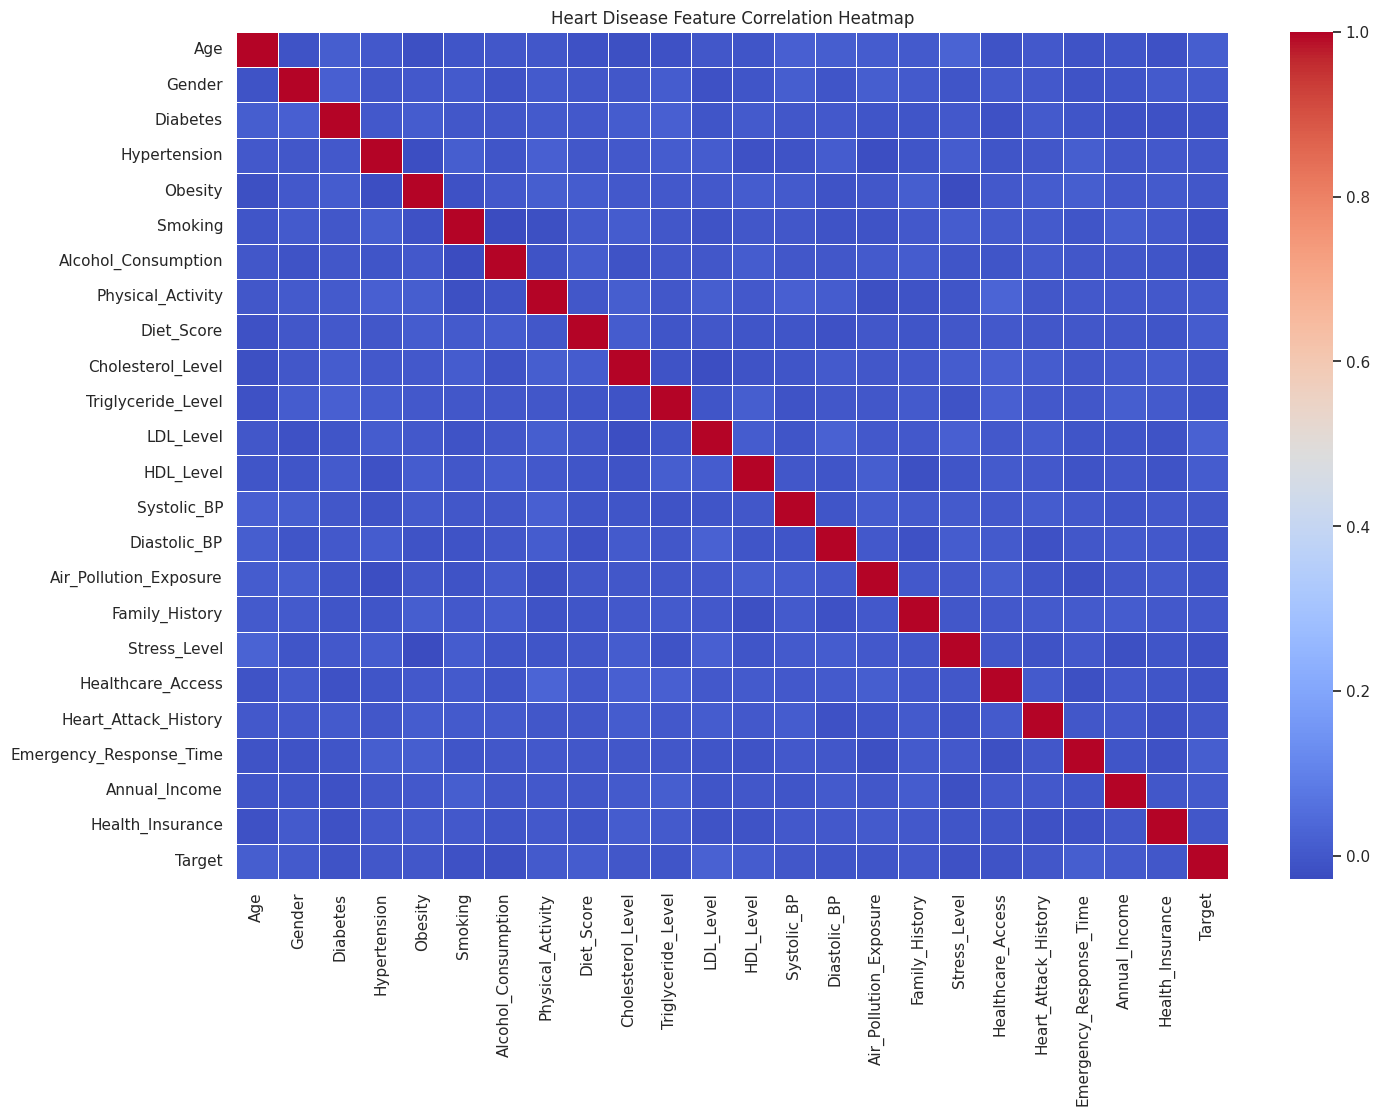

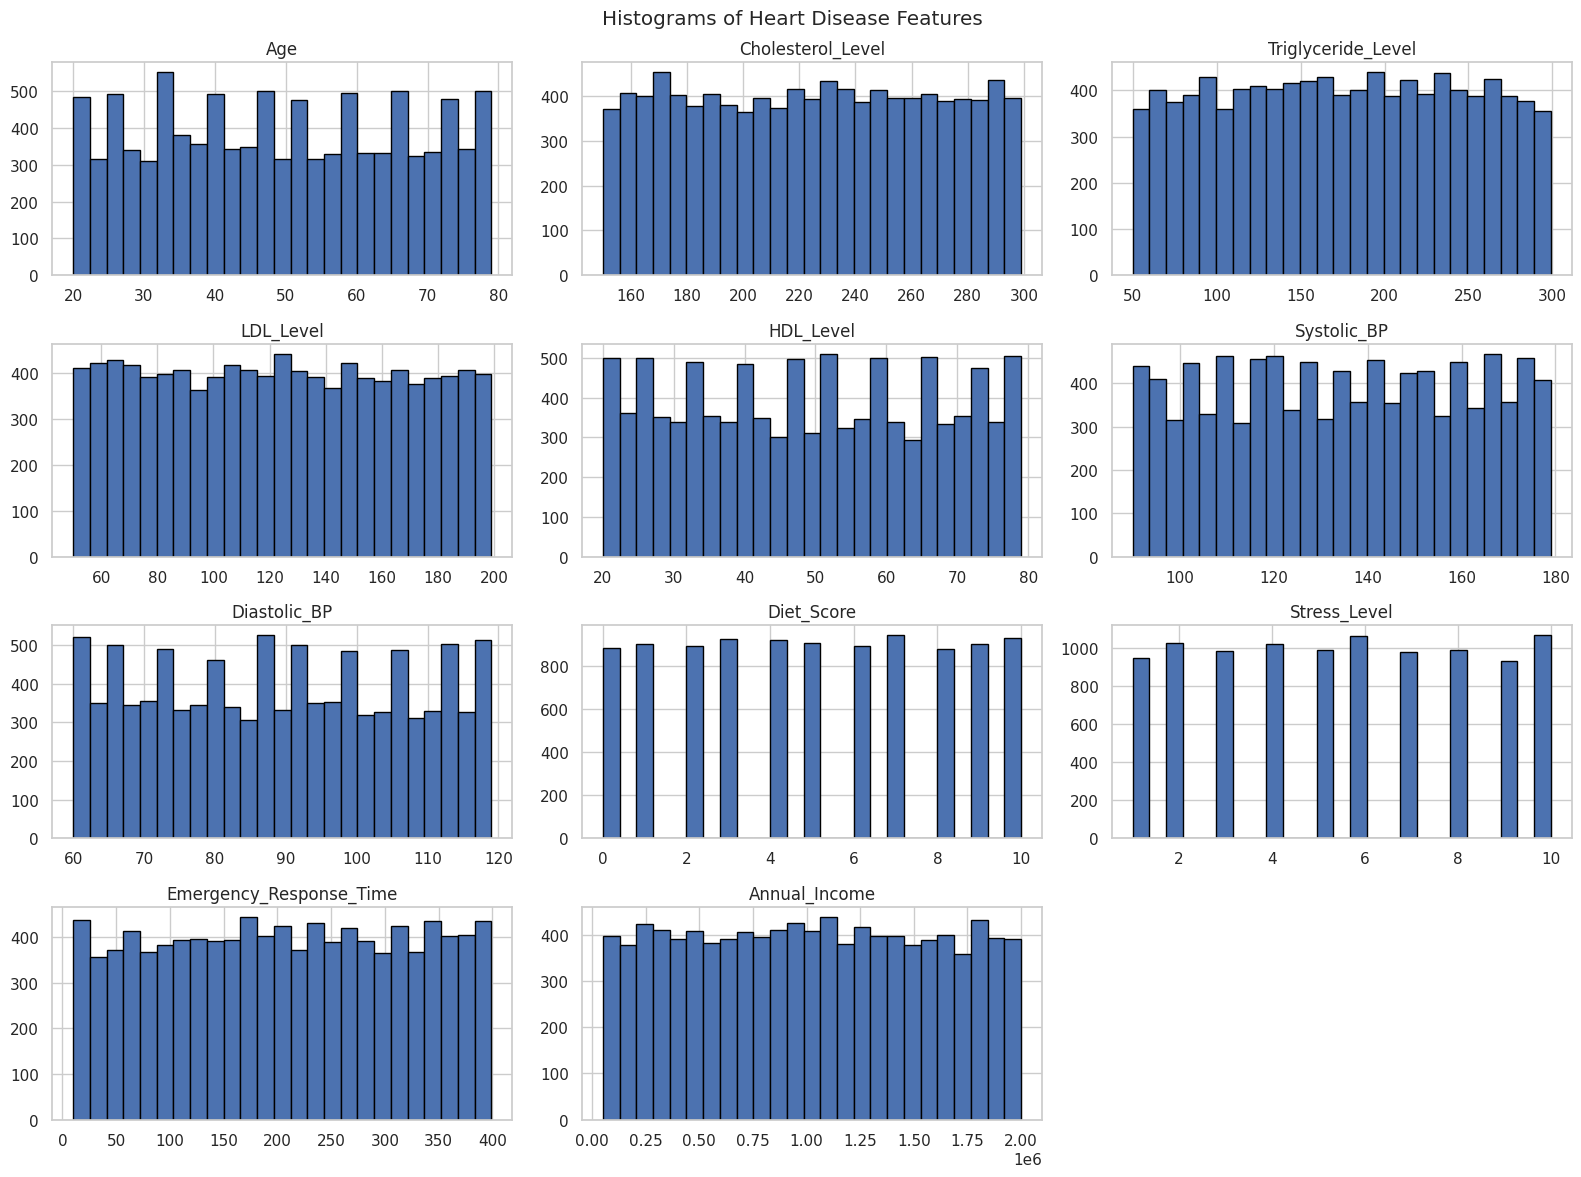

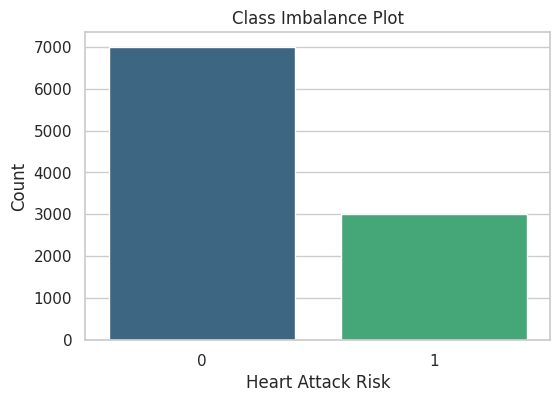

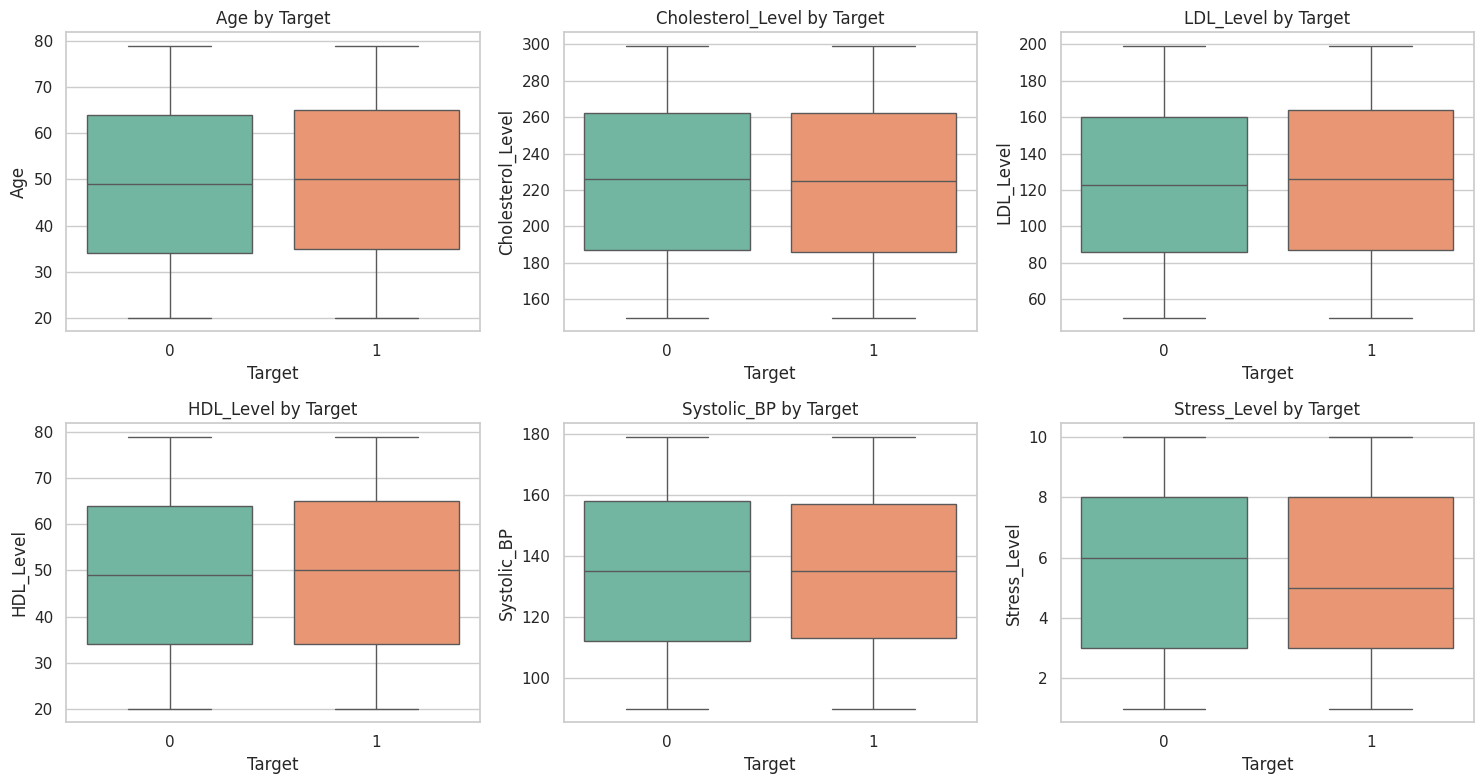

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. Correlation Heatmap
plt.figure(figsize=(16, 11))
corr_matrix = df.drop(columns=['State_Name']).corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5)
plt.title("Heart Disease Feature Correlation Heatmap")
plt.show()

# 2. Histograms
plot_cols = [
    'Age', 'Cholesterol_Level', 'Triglyceride_Level', 'LDL_Level', 'HDL_Level',
    'Systolic_BP', 'Diastolic_BP', 'Diet_Score', 'Stress_Level',
    'Emergency_Response_Time', 'Annual_Income'
]
df[plot_cols].hist(figsize=(16, 12), bins=25, edgecolor='black')
plt.suptitle("Histograms of Heart Disease Features")
plt.tight_layout()
plt.show()

# 3. Class Imbalance Plot
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Target'], palette='viridis')
plt.title("Class Imbalance Plot")
plt.xlabel("Heart Attack Risk")
plt.ylabel("Count")
plt.show()

# 4. Boxplots for clinical continuous features by target
box_cols = ['Age', 'Cholesterol_Level', 'LDL_Level', 'HDL_Level', 'Systolic_BP', 'Stress_Level']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df, x='Target', y=col, ax=ax, palette='Set2')
    ax.set_title(f"{col} by Target")
plt.tight_layout()
plt.show()


# CAUSAL STRUCTURE LEARNING


## Discretize Features


In [10]:
def qcut_labels(series, labels):
    return pd.qcut(series.rank(method='first'), q=len(labels), labels=labels)

df['Age_bin'] = pd.cut(
    df['Age'],
    bins=[0, 40, 60, 120],
    labels=['young', 'middle', 'old'],
    include_lowest=True
)

df['Cholesterol_bin'] = pd.cut(
    df['Cholesterol_Level'],
    bins=[0, 200, 240, np.inf],
    labels=['normal', 'borderline', 'high'],
    include_lowest=True
)

df['LDL_bin'] = pd.cut(
    df['LDL_Level'],
    bins=[0, 100, 130, np.inf],
    labels=['optimal', 'borderline', 'high'],
    include_lowest=True
)

df['HDL_bin'] = pd.cut(
    df['HDL_Level'],
    bins=[0, 40, 60, np.inf],
    labels=['low', 'normal', 'high'],
    include_lowest=True
)

df['Triglyceride_bin'] = pd.cut(
    df['Triglyceride_Level'],
    bins=[0, 150, 200, np.inf],
    labels=['normal', 'borderline', 'high'],
    include_lowest=True
)

df['Systolic_BP_bin'] = pd.cut(
    df['Systolic_BP'],
    bins=[0, 120, 130, 140, np.inf],
    labels=['normal', 'elevated', 'stage1', 'stage2'],
    include_lowest=True
)

df['Diastolic_BP_bin'] = pd.cut(
    df['Diastolic_BP'],
    bins=[0, 80, 90, np.inf],
    labels=['normal', 'stage1', 'stage2'],
    include_lowest=True
)

df['Diet_bin'] = pd.cut(
    df['Diet_Score'],
    bins=[-1, 3, 7, 10],
    labels=['poor', 'average', 'good'],
    include_lowest=True
)

df['Stress_bin'] = pd.cut(
    df['Stress_Level'],
    bins=[0, 3, 7, 10],
    labels=['low', 'medium', 'high'],
    include_lowest=True
)

df['Income_bin'] = qcut_labels(df['Annual_Income'], ['low', 'middle', 'high'])
df['Response_bin'] = qcut_labels(df['Emergency_Response_Time'], ['fast', 'medium', 'slow'])

bayesian_df = df[
    [
        'Age_bin', 'Gender', 'Diabetes', 'Hypertension', 'Obesity', 'Smoking',
        'Alcohol_Consumption', 'Physical_Activity', 'Diet_bin',
        'Cholesterol_bin', 'Triglyceride_bin', 'LDL_bin', 'HDL_bin',
        'Systolic_BP_bin', 'Diastolic_BP_bin', 'Air_Pollution_Exposure',
        'Family_History', 'Stress_bin', 'Healthcare_Access',
        'Heart_Attack_History', 'Health_Insurance', 'Income_bin',
        'Response_bin', 'Target'
    ]
].copy()

for col in bayesian_df.columns:
    bayesian_df[col] = bayesian_df[col].astype(str)

bayesian_df.head()


,Age_bin,Gender,Diabetes,Hypertension,Obesity,Smoking,Alcohol_Consumption,Physical_Activity,Diet_bin,Cholesterol_bin,...,Diastolic_BP_bin,Air_Pollution_Exposure,Family_History,Stress_bin,Healthcare_Access,Heart_Attack_History,Health_Insurance,Income_bin,Response_bin,Target
0,middle,0,0,0,1,1,0,0,good,high,...,stage2,1,0,medium,0,0,0,low,medium,0
1,young,1,0,0,0,0,1,1,average,high,...,stage2,0,0,medium,0,0,0,low,slow,0
2,old,1,0,0,1,0,0,1,average,high,...,stage2,0,1,high,1,0,1,high,medium,0
3,middle,1,1,0,1,0,0,1,good,borderline,...,normal,0,0,low,1,1,0,high,slow,0
4,young,1,0,0,0,0,0,1,average,high,...,stage2,0,0,high,0,0,0,low,medium,1


In [11]:
!pip install pgmpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 8.2 MB/s eta 0:00:00


## Learn DAG Structure


In [12]:
try:
    from pgmpy.estimators import HillClimbSearch, BIC, ExpertKnowledge
except ImportError:
    from pgmpy.estimators import HillClimbSearch, BicScore as BIC, ExpertKnowledge

# Structure learning can be slow with many columns. Use a clinically focused subset for the DAG.
dag_cols = [
    'Age_bin', 'Gender', 'Diabetes', 'Hypertension', 'Obesity', 'Smoking',
    'Physical_Activity', 'Diet_bin', 'Cholesterol_bin', 'LDL_bin', 'HDL_bin',
    'Systolic_BP_bin', 'Diastolic_BP_bin', 'Family_History', 'Stress_bin',
    'Heart_Attack_History', 'Target'
]
df_discrete = bayesian_df[dag_cols].copy()

hc = HillClimbSearch(df_discrete)
best_structure = hc.estimate(scoring_method=BIC(df_discrete))
print(best_structure.edges())


  0%|          | 0/1000000 [00:00<?, ?it/s]

[]


In [13]:
forbidden_edges = [
    ('Target', 'Age_bin'),
    ('Target', 'Gender'),
    ('Target', 'Family_History'),
    ('Target', 'Smoking'),
    ('Target', 'Diabetes'),
    ('Target', 'Hypertension'),
    ('Cholesterol_bin', 'Age_bin'),
    ('LDL_bin', 'Gender'),
    ('Systolic_BP_bin', 'Gender'),
]

required_edges = [
    ('LDL_bin', 'Cholesterol_bin'),
    ('Systolic_BP_bin', 'Hypertension'),
    ('Hypertension', 'Target'),
]

expert_knowledge = ExpertKnowledge(
    forbidden_edges=forbidden_edges,
    required_edges=required_edges
)

hc = HillClimbSearch(df_discrete)
best_structure = hc.estimate(
    scoring_method=BIC(df_discrete),
    expert_knowledge=expert_knowledge
)

print(best_structure.edges())


  0%|          | 0/1000000 [00:00<?, ?it/s]

[('Hypertension', 'Target'), ('LDL_bin', 'Cholesterol_bin'), ('Systolic_BP_bin', 'Hypertension')]


## DAG


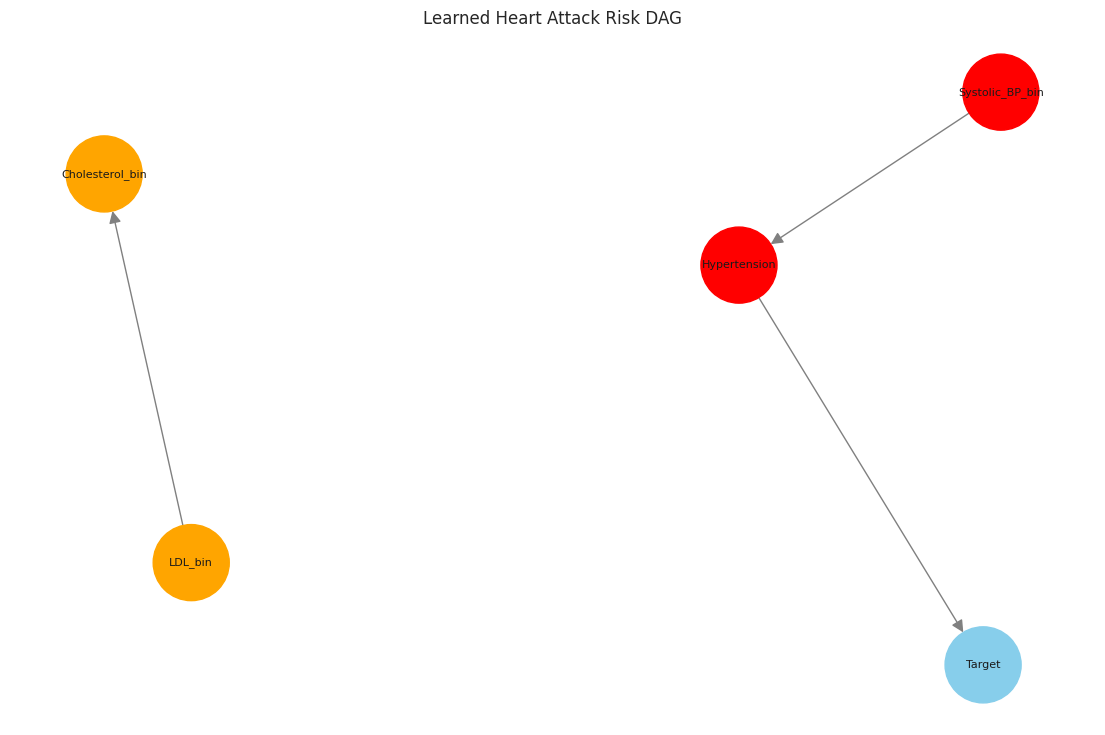

In [14]:
import os
import networkx as nx
import matplotlib.pyplot as plt

os.makedirs("heart_figures", exist_ok=True)

G = nx.DiGraph()
learned_edges = list(best_structure.edges())
G.add_edges_from(learned_edges)

node_colors = []
for node in G.nodes():
    if node in ['Cholesterol_bin', 'Triglyceride_bin', 'LDL_bin', 'HDL_bin']:
        node_colors.append('orange')
    elif node in ['Systolic_BP_bin', 'Diastolic_BP_bin', 'Hypertension']:
        node_colors.append('red')
    elif node in ['Smoking', 'Obesity', 'Diabetes', 'Physical_Activity', 'Diet_bin']:
        node_colors.append('green')
    elif node == 'Target':
        node_colors.append('skyblue')
    else:
        node_colors.append('lightgray')

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=1.4)
nx.draw_networkx(
    G, pos,
    with_labels=True,
    node_size=3000,
    font_size=8,
    arrowsize=18,
    node_color=node_colors,
    edge_color='gray'
)
plt.title("Learned Heart Attack Risk DAG")
plt.axis('off')
plt.savefig("heart_figures/learned_dag.png", dpi=300, bbox_inches='tight')
plt.show()


In [15]:
expert_edges = [
    ('Age_bin', 'Hypertension'),
    ('Age_bin', 'Diabetes'),
    ('Gender', 'Smoking'),
    ('Family_History', 'Target'),
    ('Smoking', 'Hypertension'),
    ('Smoking', 'Target'),
    ('Obesity', 'Diabetes'),
    ('Obesity', 'Hypertension'),
    ('Physical_Activity', 'Obesity'),
    ('Diet_bin', 'Obesity'),
    ('Diet_bin', 'Cholesterol_bin'),
    ('LDL_bin', 'Cholesterol_bin'),
    ('HDL_bin', 'Cholesterol_bin'),
    ('Triglyceride_bin', 'Cholesterol_bin'),
    ('Systolic_BP_bin', 'Hypertension'),
    ('Diastolic_BP_bin', 'Hypertension'),
    ('Diabetes', 'Target'),
    ('Hypertension', 'Target'),
    ('Cholesterol_bin', 'Target'),
    ('Heart_Attack_History', 'Target'),
    ('Stress_bin', 'Target'),
]


## Comparing with Clinical DAG


In [16]:
validation = []
for edge in learned_edges:
    validity = "Yes" if edge in expert_edges else "No/Partial"
    validation.append([edge, validity])

for row in validation:
    print(row)


[('Hypertension', 'Target'), 'Yes']
[('LDL_bin', 'Cholesterol_bin'), 'Yes']
[('Systolic_BP_bin', 'Hypertension'), 'Yes']


## Structural Hamming Distance


In [17]:
expert_set = set(expert_edges)
learned_set = set(learned_edges)

extra_edges = learned_set - expert_set
missing_edges = expert_set - learned_set
shd = len(extra_edges) + len(missing_edges)

print("Extra edges:", extra_edges)
print("Missing edges:", missing_edges)
print("SHD:", shd)

pd.DataFrame(validation, columns=['Learned Edge', 'Clinically Valid']).to_csv(
    "heart_clinical_validation.csv",
    index=False
)


Extra edges: set()
Missing edges: {('Obesity', 'Hypertension'), ('Diastolic_BP_bin', 'Hypertension'), ('Gender', 'Smoking'), ('Physical_Activity', 'Obesity'), ('Family_History', 'Target'), ('Age_bin', 'Diabetes'), ('Diet_bin', 'Cholesterol_bin'), ('Heart_Attack_History', 'Target'), ('Diabetes', 'Target'), ('Smoking', 'Hypertension'), ('Age_bin', 'Hypertension'), ('Triglyceride_bin', 'Cholesterol_bin'), ('Stress_bin', 'Target'), ('Obesity', 'Diabetes'), ('Cholesterol_bin', 'Target'), ('Diet_bin', 'Obesity'), ('Smoking', 'Target'), ('HDL_bin', 'Cholesterol_bin')}
SHD: 18


# BAYESIAN NETWORK TRAINING


## Learned Model


In [18]:
try:
    from pgmpy.models import DiscreteBayesianNetwork
except ImportError:
    from pgmpy.models import BayesianNetwork as DiscreteBayesianNetwork

learned_model = DiscreteBayesianNetwork(best_structure.edges())
learned_model.add_nodes_from(df_discrete.columns)
learned_model.fit(df_discrete)


## Conditional Probability Tables


In [19]:
with open("heart_all_cpds.txt", "w") as f:
    for cpd in learned_model.get_cpds():
        f.write(str(cpd))
        f.write("\n\n" + "="*80 + "\n\n")
        print(cpd)
        print("\n")


+-----------------+-----+-------------------------+
| Systolic_BP_bin | ... | Systolic_BP_bin(stage2) |
+-----------------+-----+-------------------------+
| Hypertension(0) | ... | 0.7528762080073631      |
+-----------------+-----+-------------------------+
| Hypertension(1) | ... | 0.2471237919926369      |
+-----------------+-----+-------------------------+


+--------------+--------------------+--------------------+
| Hypertension | Hypertension(0)    | Hypertension(1)    |
+--------------+--------------------+--------------------+
| Target(0)    | 0.6989775594210597 | 0.7002835155933577 |
+--------------+--------------------+--------------------+
| Target(1)    | 0.3010224405789404 | 0.2997164844066424 |
+--------------+--------------------+--------------------+


+---------------------+--------+
| LDL_bin(borderline) | 0.2076 |
+---------------------+--------+
| LDL_bin(high)       | 0.4514 |
+---------------------+--------+
| LDL_bin(optimal)    | 0.341  |
+--------------------

In [20]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(learned_model)
positive_label = '1'

def target_probability(query_result, positive_label='1'):
    states = list(query_result.state_names['Target'])
    return float(query_result.values[states.index(positive_label)])

queries = [
    {'Hypertension': '1', 'Smoking': '1'},
    {'LDL_bin': 'high', 'Systolic_BP_bin': 'stage2', 'Diabetes': '1'},
    {'Heart_Attack_History': '1'},
]

for evidence in queries:
    filtered_evidence = {k: v for k, v in evidence.items() if k in learned_model.nodes()}
    q = infer.query(variables=['Target'], evidence=filtered_evidence)
    print("Evidence:", filtered_evidence)
    print(q)


Evidence: {'Hypertension': '1', 'Smoking': '1'}
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(0) |        0.7003 |
+-----------+---------------+
| Target(1) |        0.2997 |
+-----------+---------------+
Evidence: {'LDL_bin': 'high', 'Systolic_BP_bin': 'stage2', 'Diabetes': '1'}
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(0) |        0.6993 |
+-----------+---------------+
| Target(1) |        0.3007 |
+-----------+---------------+
Evidence: {'Heart_Attack_History': '1'}
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(0) |        0.6993 |
+-----------+---------------+
| Target(1) |        0.3007 |
+-----------+---------------+


In [21]:
print(learned_model.get_cpds('Target'))


+--------------+--------------------+--------------------+
| Hypertension | Hypertension(0)    | Hypertension(1)    |
+--------------+--------------------+--------------------+
| Target(0)    | 0.6989775594210597 | 0.7002835155933577 |
+--------------+--------------------+--------------------+
| Target(1)    | 0.3010224405789404 | 0.2997164844066424 |
+--------------+--------------------+--------------------+


## Expert Model


In [22]:
# Keep only expert edges whose nodes are present in the DAG data.
expert_edges_model = [
    edge for edge in expert_edges
    if edge[0] in df_discrete.columns and edge[1] in df_discrete.columns
]

expert_model = DiscreteBayesianNetwork(expert_edges_model)
expert_model.add_nodes_from(df_discrete.columns)
expert_model.fit(df_discrete)


# PROBABILISTIC INFERENCE


## Patient-Level Risk Prediction


In [23]:
infer_learned = VariableElimination(learned_model)
infer_expert = VariableElimination(expert_model)

query = {
    'Hypertension': '1',
    'Smoking': '1',
    'LDL_bin': 'high'
}
query = {k: v for k, v in query.items() if k in learned_model.nodes()}

q1 = infer_learned.query(variables=['Target'], evidence=query)
print("Learned model")
print(q1)

query_expert = {k: v for k, v in query.items() if k in expert_model.nodes()}
q2 = infer_expert.query(variables=['Target'], evidence=query_expert)
print("Expert model")
print(q2)


Learned model
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(0) |        0.7003 |
+-----------+---------------+
| Target(1) |        0.2997 |
+-----------+---------------+
Expert model
+-----------+---------------+
| Target    |   phi(Target) |
+===========+===============+
| Target(0) |        0.6938 |
+-----------+---------------+
| Target(1) |        0.3062 |
+-----------+---------------+


## Comparison between Learned and Expert Model


In [24]:
y_true = df_discrete['Target']


def predict(model_infer, row, model_nodes):
    evidence = {
        k: v
        for k, v in row.items()
        if k in model_nodes and k != 'Target'
    }
    q = model_infer.query(variables=['Target'], evidence=evidence)
    probs = q.values
    pred = q.state_names['Target'][probs.argmax()]
    return pred

learned_nodes = set(learned_model.nodes())
expert_nodes = set(expert_model.nodes())

y_pred_learned = []
y_pred_expert = []

for _, row in df_discrete.iterrows():
    y_pred_learned.append(predict(infer_learned, row, learned_nodes))
    y_pred_expert.append(predict(infer_expert, row, expert_nodes))


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Learned DAG")
print("Accuracy", accuracy_score(y_true, y_pred_learned))
print("Precision", precision_score(y_true, y_pred_learned, pos_label=positive_label, zero_division=0))
print("Recall", recall_score(y_true, y_pred_learned, pos_label=positive_label, zero_division=0))
print("F1 score", f1_score(y_true, y_pred_learned, pos_label=positive_label, zero_division=0))

print("\nExpert DAG")
print("Accuracy", accuracy_score(y_true, y_pred_expert))
print("Precision", precision_score(y_true, y_pred_expert, pos_label=positive_label, zero_division=0))
print("Recall", recall_score(y_true, y_pred_expert, pos_label=positive_label, zero_division=0))
print("F1 score", f1_score(y_true, y_pred_expert, pos_label=positive_label, zero_division=0))


Learned DAG
Accuracy 0.6993
Precision 0.0
Recall 0.0
F1 score 0.0

Expert DAG
Accuracy 0.7022
Precision 0.6986301369863014
Recall 0.016960425673428665
F1 score 0.033116883116883114


# UNCERTAINTY AWARENESS


## Bootstrap Sampling


In [26]:
N = 100
risk_scores = []
evidence = {'Hypertension': '1', 'Smoking': '1'}
evidence = {k: v for k, v in evidence.items() if k in learned_model.nodes()}

for i in range(N):
    sample_df = df_discrete.sample(n=len(df_discrete), replace=True, random_state=i)
    bootstrap_model = DiscreteBayesianNetwork(best_structure.edges())
    bootstrap_model.add_nodes_from(df_discrete.columns)
    bootstrap_model.fit(sample_df)
    bootstrap_infer = VariableElimination(bootstrap_model)
    q = bootstrap_infer.query(variables=['Target'], evidence=evidence)
    risk_scores.append(target_probability(q, positive_label=positive_label))

mean_risk = np.mean(risk_scores)
std_risk = np.std(risk_scores)
lower = mean_risk - 1.96 * std_risk
upper = mean_risk + 1.96 * std_risk

print(f"Risk = {mean_risk:.2f} ? {std_risk:.2f}")
print(f"95% CI = [{lower:.2f}, {upper:.2f}]")


Risk = 0.30 ? 0.01
95% CI = [0.28, 0.32]


## Uncertainty Distribution


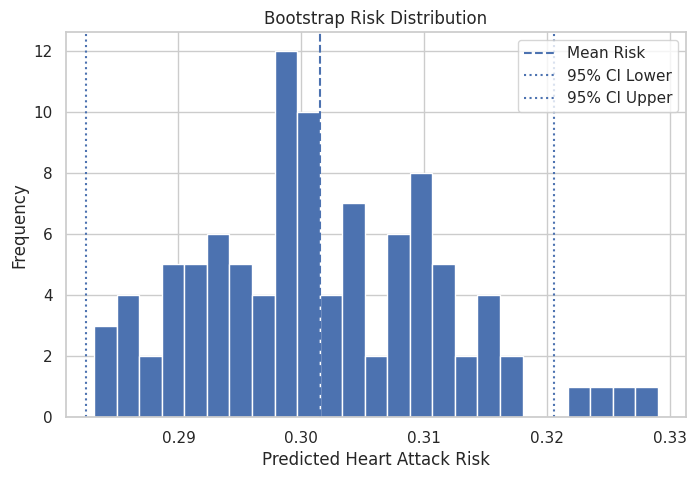

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(risk_scores, bins=25)
plt.axvline(mean_risk, linestyle='--', label='Mean Risk')
plt.axvline(lower, linestyle=':', label='95% CI Lower')
plt.axvline(upper, linestyle=':', label='95% CI Upper')
plt.xlabel("Predicted Heart Attack Risk")
plt.ylabel("Frequency")
plt.title("Bootstrap Risk Distribution")
plt.legend()
plt.savefig("heart_figures/bootstrap_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()


# COUNTERFACTUAL INTERVENTION ENGINE


In [28]:
infer = VariableElimination(learned_model)

def get_risk(evidence):
    filtered_evidence = {k: v for k, v in evidence.items() if k in learned_model.nodes()}
    q = infer.query(variables=['Target'], evidence=filtered_evidence)
    return target_probability(q, positive_label=positive_label)

patient = {
    'Hypertension': '1',
    'Smoking': '1',
    'LDL_bin': 'high'
}

old_risk = get_risk(patient)
print("Old Risk:", old_risk)

intervention = {
    'Hypertension': '0',
    'Smoking': '0',
    'LDL_bin': 'optimal'
}

new_risk = get_risk(intervention)
print("New Risk:", new_risk)


Old Risk: 0.2997164844066424
New Risk: 0.3010224405789404


## Intervention Comparison Table


In [29]:
results = [
    ['Control blood pressure', old_risk, get_risk({'Hypertension': '0', 'Smoking': '1', 'LDL_bin': 'high'})],
    ['Stop smoking', old_risk, get_risk({'Hypertension': '1', 'Smoking': '0', 'LDL_bin': 'high'})],
    ['Improve LDL', old_risk, get_risk({'Hypertension': '1', 'Smoking': '1', 'LDL_bin': 'optimal'})],
    ['Combined intervention', old_risk, new_risk],
]

df_interventions = pd.DataFrame(results, columns=['Intervention', 'Risk Before', 'Risk After'])
print(df_interventions)
df_interventions.to_csv("heart_intervention_results.csv", index=False)


             Intervention  Risk Before  Risk After
0  Control blood pressure     0.299716    0.301022
1            Stop smoking     0.299716    0.299716
2             Improve LDL     0.299716    0.299716
3   Combined intervention     0.299716    0.301022


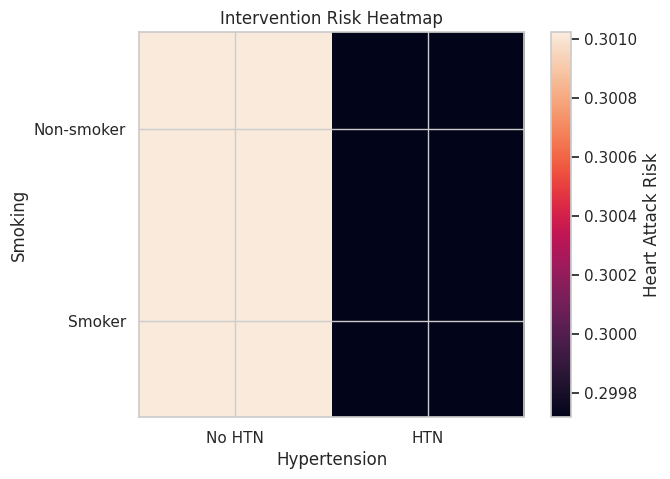

In [30]:
hypertension_levels = ['0', '1']
smoking_levels = ['0', '1']

heatmap_data = []
for smoking in smoking_levels:
    row = []
    for hypertension in hypertension_levels:
        row.append(get_risk({'Hypertension': hypertension, 'Smoking': smoking}))
    heatmap_data.append(row)

plt.figure(figsize=(7, 5))
plt.imshow(heatmap_data)
plt.colorbar(label='Heart Attack Risk')
plt.xticks(range(len(hypertension_levels)), ['No HTN', 'HTN'])
plt.yticks(range(len(smoking_levels)), ['Non-smoker', 'Smoker'])
plt.xlabel("Hypertension")
plt.ylabel("Smoking")
plt.title("Intervention Risk Heatmap")
plt.savefig("heart_figures/intervention_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


# OPTIMIZATION ENGINE


In [31]:
patient = {'Hypertension': '1', 'Smoking': '1', 'LDL_bin': 'high'}
baseline_risk = get_risk(patient)
print(baseline_risk)


0.2997164844066424


In [32]:
target_risk = 0.30
ldl_levels = ['optimal', 'borderline', 'high']
results = []

for hypertension in hypertension_levels:
    for smoking in smoking_levels:
        for ldl in ldl_levels:
            intervention = {'Hypertension': hypertension, 'Smoking': smoking, 'LDL_bin': ldl}
            risk = get_risk(intervention)
            distance = (
                int(hypertension != patient['Hypertension']) +
                int(smoking != patient['Smoking']) +
                int(ldl != patient['LDL_bin'])
            )
            results.append([hypertension, smoking, ldl, risk, distance])

df_opt = pd.DataFrame(results, columns=['Hypertension', 'Smoking', 'LDL_bin', 'Risk', 'Distance'])
safe_df = df_opt[df_opt['Risk'] < target_risk]

if len(safe_df) == 0:
    print("No feasible intervention found.")
    print("Minimum achievable risk:", df_opt['Risk'].min())
else:
    best = safe_df.sort_values(by=['Distance', 'Risk']).iloc[0]
    print(best)

print(df_opt.sort_values(by='Risk'))


Hypertension           1
Smoking                1
LDL_bin             high
Risk            0.299716
Distance               0
Name: 11, dtype: object
   Hypertension Smoking     LDL_bin      Risk  Distance
6             1       0     optimal  0.299716         2
7             1       0  borderline  0.299716         2
9             1       1     optimal  0.299716         1
8             1       0        high  0.299716         1
11            1       1        high  0.299716         0
10            1       1  borderline  0.299716         1
0             0       0     optimal  0.301022         3
1             0       0  borderline  0.301022         3
4             0       1  borderline  0.301022         2
5             0       1        high  0.301022         1
2             0       0        high  0.301022         2
3             0       1     optimal  0.301022         2


## Training ML Baselines


In [33]:
!pip install imbalanced-learn catboost


In [34]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

X = df.drop(columns=['Target'])
y = df['Target'].astype(str)
positive_label = '1'

categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', one_hot, categorical_features),
    ],
    remainder='drop'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'SVM RBF': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB(),
}

try:
    from catboost import CatBoostClassifier
    base_models['CatBoost'] = CatBoostClassifier(verbose=False, random_state=42, auto_class_weights='Balanced')
except Exception:
    print("CatBoost is not available; continuing with sklearn models.")

voting_estimators = [
    ('lr', LogisticRegression(max_iter=3000, class_weight='balanced')),
    ('rf', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced')),
    ('et', ExtraTreesClassifier(n_estimators=250, random_state=42, class_weight='balanced')),
    ('gb', GradientBoostingClassifier(random_state=42)),
]

base_models['Soft Voting Ensemble'] = VotingClassifier(
    estimators=voting_estimators,
    voting='soft'
)

base_models['Stacking Ensemble'] = StackingClassifier(
    estimators=voting_estimators,
    final_estimator=LogisticRegression(max_iter=3000, class_weight='balanced'),
    stack_method='predict_proba',
    cv=3,
    n_jobs=-1
)

trained_models = {}
model_rows = []

for name, estimator in base_models.items():
    print(f"Training {name}...")
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    classes = list(model.classes_)
    pos_idx = classes.index(positive_label) if positive_label in classes else -1
    y_prob = model.predict_proba(X_test)[:, pos_idx]

    model_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        'Recall': recall_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        'AUC Score': roc_auc_score((y_test == positive_label).astype(int), y_prob),
    })
    trained_models[name] = model

model_results = pd.DataFrame(model_rows).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
print("\n===== ML MODEL COMPARISON =====\n")
print(model_results)
model_results.to_csv("heart_ml_model_comparison.csv", index=False)

best_ml_row = model_results.iloc[0]
print("\nBest ML model:", best_ml_row['Model'])


Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training AdaBoost...
Training SVM RBF...
Training KNN...
Training Naive Bayes...
Training CatBoost...
Training Soft Voting Ensemble...
Training Stacking Ensemble...

===== ML MODEL COMPARISON =====

                   Model  Accuracy  Precision    Recall  F1 Score  AUC Score
0      Stacking Ensemble    0.5005   0.302187  0.505824  0.378345   0.495443
1    Logistic Regression    0.5035   0.294979  0.469218  0.362235   0.493271
2                SVM RBF    0.5065   0.278161  0.402662  0.329028   0.479646
3            Naive Bayes    0.5920   0.299814  0.267887  0.282953   0.518576
4          Decision Tree    0.5710   0.284034  0.281198  0.282609   0.488347
5               CatBoost    0.5800   0.284685  0.262895  0.273356   0.491428
6                    KNN    0.6440   0.292135  0.129784  0.179724   0.521648
7      Gradient Boosting    0.6980   0.333333  

## All Models vs Bayesian Network



===== ALL MODELS vs BAYESIAN NETWORK =====

                   Model  Accuracy  Precision    Recall  F1 Score  AUC Score
0      Stacking Ensemble    0.5005   0.302187  0.505824  0.378345   0.495443
1    Logistic Regression    0.5035   0.294979  0.469218  0.362235   0.493271
2                SVM RBF    0.5065   0.278161  0.402662  0.329028   0.479646
3            Naive Bayes    0.5920   0.299814  0.267887  0.282953   0.518576
4          Decision Tree    0.5710   0.284034  0.281198  0.282609   0.488347
5               CatBoost    0.5800   0.284685  0.262895  0.273356   0.491428
6                    KNN    0.6440   0.292135  0.129784  0.179724   0.521648
7      Gradient Boosting    0.6980   0.333333  0.004992  0.009836   0.488887
8            Extra Trees    0.6985   0.000000  0.000000  0.000000   0.499430
9          Random Forest    0.6995   0.000000  0.000000  0.000000   0.474855
10              AdaBoost    0.6995   0.000000  0.000000  0.000000   0.483981
11  Soft Voting Ensemble    0.6

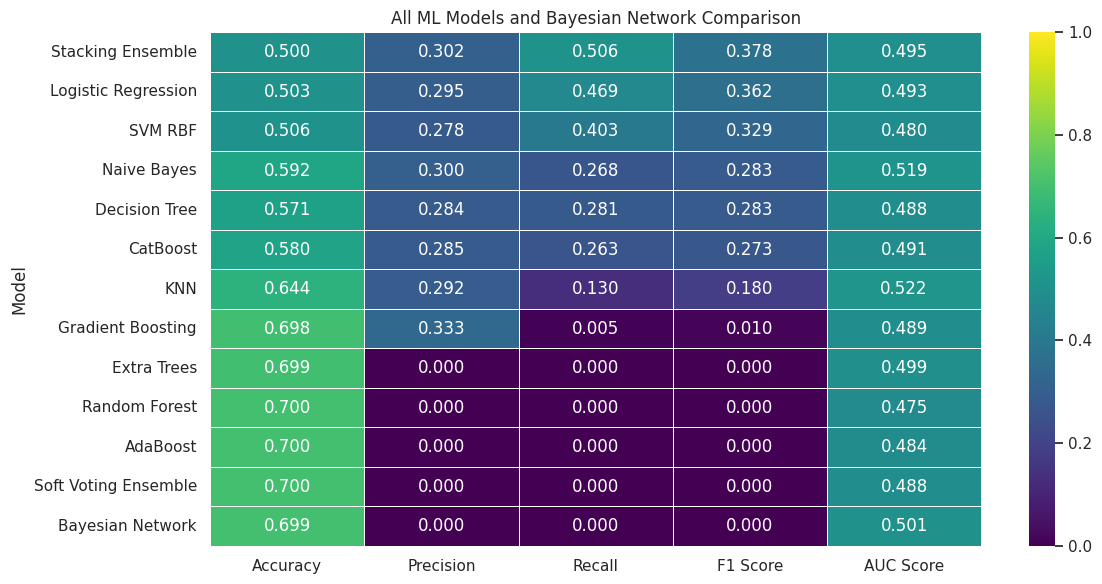

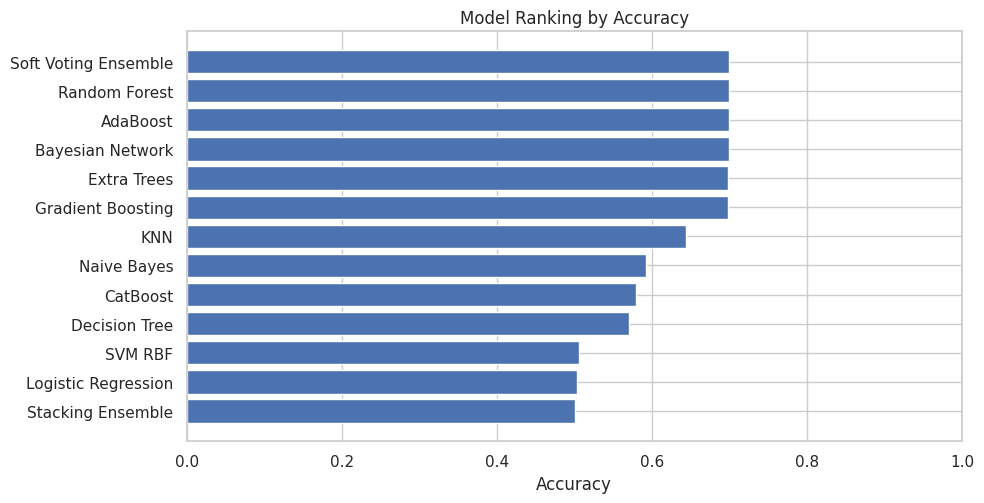

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

bn_accuracy = accuracy_score(y_true, y_pred_learned)
bn_precision = precision_score(y_true, y_pred_learned, pos_label=positive_label, zero_division=0)
bn_recall = recall_score(y_true, y_pred_learned, pos_label=positive_label, zero_division=0)
bn_f1 = f1_score(y_true, y_pred_learned, pos_label=positive_label, zero_division=0)

bn_probs = []
for _, row in df_discrete.iterrows():
    evidence = {k: v for k, v in row.items() if k in learned_nodes and k != 'Target'}
    q = infer_learned.query(variables=['Target'], evidence=evidence)
    bn_probs.append(target_probability(q, positive_label=positive_label))

bn_auc = roc_auc_score((y_true == positive_label).astype(int), bn_probs)

bn_row = {
    'Model': 'Bayesian Network',
    'Accuracy': bn_accuracy,
    'Precision': bn_precision,
    'Recall': bn_recall,
    'F1 Score': bn_f1,
    'AUC Score': bn_auc,
}

all_results = pd.concat(
    [model_results, pd.DataFrame([bn_row])],
    ignore_index=True
).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

print("\n===== ALL MODELS vs BAYESIAN NETWORK =====\n")
print(all_results)
all_results.to_csv("heart_all_models_vs_bayesian.csv", index=False)

import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("heart_figures", exist_ok=True)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC Score']
plot_df = all_results.set_index('Model')[metrics]

plt.figure(figsize=(12, max(6, 0.45 * len(plot_df))))
sns.heatmap(
    plot_df,
    annot=True,
    cmap='viridis',
    fmt='.3f',
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title("All ML Models and Bayesian Network Comparison")
plt.tight_layout()
plt.savefig("heart_figures/all_models_vs_bayesian_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

ranked = all_results.sort_values(by='Accuracy', ascending=True)
plt.figure(figsize=(10, max(5, 0.4 * len(ranked))))
plt.barh(ranked['Model'], ranked['Accuracy'])
plt.xlabel("Accuracy")
plt.title("Model Ranking by Accuracy")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("heart_figures/model_f1_ranking.png", dpi=300, bbox_inches='tight')
plt.show()


# LLM EXPLANATION


In [38]:
!pip install groq

In [40]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GROQ_API_KEY")

In [43]:
from groq import Groq
client = Groq(api_key=secret_value_0)

dag_edges = list(learned_model.edges())
risk = round(old_risk, 4)
confidence_interval = [round(lower, 4), round(upper, 4)]
interventions = df_interventions.to_dict(orient='records')

prompt = f"""
You are an AI clinical reasoning assistant.

A Bayesian causal network was trained for heart attack risk analysis.
The modeled positive label is {positive_label}.

Learned causal DAG edges:
{dag_edges}

Predicted heart attack risk:
{risk}

95% confidence interval:
{confidence_interval}

Intervention analysis:
{interventions}

Generate:
1. Primary risk drivers
2. Interpretable clinical explanation
3. Intervention summary
4. Confidence and uncertainty notes
"""

print(prompt)

# response = client.chat.completions.create(
#     model="llama-3.1-8b-instant",
#     messages=[{"role": "user", "content": prompt}],
# )
# print(response.choices[0].message.content)



You are an AI clinical reasoning assistant.

A Bayesian causal network was trained for heart attack risk analysis.
The modeled positive label is 1.

Learned causal DAG edges:
[('Hypertension', 'Target'), ('LDL_bin', 'Cholesterol_bin'), ('Systolic_BP_bin', 'Hypertension')]

Predicted heart attack risk:
0.2997

95% confidence interval:
[np.float64(0.2824), np.float64(0.3206)]

Intervention analysis:
[{'Intervention': 'Control blood pressure', 'Risk Before': 0.2997164844066424, 'Risk After': 0.3010224405789404}, {'Intervention': 'Stop smoking', 'Risk Before': 0.2997164844066424, 'Risk After': 0.2997164844066424}, {'Intervention': 'Improve LDL', 'Risk Before': 0.2997164844066424, 'Risk After': 0.2997164844066424}, {'Intervention': 'Combined intervention', 'Risk Before': 0.2997164844066424, 'Risk After': 0.3010224405789404}]

Generate:
1. Primary risk drivers
2. Interpretable clinical explanation
3. Intervention summary
4. Confidence and uncertainty notes



# EVALUATION


In [44]:
best_overall_row = all_results.sort_values(by='F1 Score', ascending=False).iloc[0]
bayesian_row = all_results[all_results['Model'] == 'Bayesian Network'].iloc[0]

final_results = pd.DataFrame({
    'Metric': [
        'Best Overall Model',
        'Best Overall Accuracy',
        'Best Overall F1 Score',
        'Best Overall AUC Score',
        'Best ML Model',
        'Bayesian Network Accuracy',
        'Bayesian Network F1 Score',
        'Bayesian Network AUC Score',
        'SHD',
        'Confidence Interval Width',
        'Risk Reduction (%)'
    ],
    'Value': [
        best_overall_row['Model'],
        round(best_overall_row['Accuracy'], 4),
        round(best_overall_row['F1 Score'], 4),
        round(best_overall_row['AUC Score'], 4),
        best_ml_row['Model'],
        round(bayesian_row['Accuracy'], 4),
        round(bayesian_row['F1 Score'], 4),
        round(bayesian_row['AUC Score'], 4),
        shd,
        round(upper - lower, 4),
        round(((old_risk - new_risk) / old_risk) * 100, 2) if old_risk else 0
    ]
})

print("\n===== FINAL SUMMARY TABLE =====\n")
print(final_results)

print("\n===== FULL MODEL COMPARISON TABLE =====\n")
print(all_results)

final_results.to_csv("heart_final_metrics_table.csv", index=False)
all_results.to_csv("heart_final_all_models_comparison.csv", index=False)



===== FINAL SUMMARY TABLE =====

                        Metric              Value
0           Best Overall Model  Stacking Ensemble
1        Best Overall Accuracy             0.5005
2        Best Overall F1 Score             0.3783
3       Best Overall AUC Score             0.4954
4                Best ML Model  Stacking Ensemble
5    Bayesian Network Accuracy             0.6993
6    Bayesian Network F1 Score                0.0
7   Bayesian Network AUC Score             0.5006
8                          SHD                 18
9    Confidence Interval Width             0.0381
10          Risk Reduction (%)              -0.44

===== FULL MODEL COMPARISON TABLE =====

                   Model  Accuracy  Precision    Recall  F1 Score  AUC Score
0      Stacking Ensemble    0.5005   0.302187  0.505824  0.378345   0.495443
1    Logistic Regression    0.5035   0.294979  0.469218  0.362235   0.493271
2                SVM RBF    0.5065   0.278161  0.402662  0.329028   0.479646
3            Nai